# Deterministic Actor-Critic: DPG, DDPG, and TD3

>- **NAME: Yashar Zafari Haqqi**
>- **STUDENT ID: 404210253**

In this notebook, the goal is to build deterministic actor-critic methods from the ground up and connect each implementation detail to the theory from the homework. We will move from the deterministic policy-gradient identity to practical deep continuous-control algorithms, and then study why DDPG can fail and how TD3 fixes several of its failure modes.

We will implement and compare the following methods:

$$
\text{DPG}
\quad\longrightarrow\quad
\text{DDPG}
\quad\longrightarrow\quad
\text{TD3}.
$$

This cell standardizes the PyTorch installation used by the notebook. It is needed if you want to use P100 on Kaggle!

First, it removes any preinstalled versions of torch, torchvision, and torchaudio. Kaggle environments often come with these packages already installed, but their versions may differ from the versions expected by this homework. The uninstall command is allowed to fail without stopping the notebook, because some of the packages may not be installed yet.

Second, it installs fixed versions of the PyTorch stack:

- torch==2.7.1
- torchvision==0.22.1
- torchaudio==2.7.1

Using exact versions makes the notebook more reproducible across students and avoids version mismatches between PyTorch, torchvision, and torchaudio.

In [18]:
# !python -m pip uninstall -y torch torchvision torchaudio || true

# !python -m pip install --no-cache-dir --force-reinstall torch==2.7.1 torchvision==0.22.1 torchaudio==2.7.1 --index-url https://download.pytorch.org/whl/cu126

This cell installs Gymnasium with MuJoCo support.

In [19]:
# !pip install "gymnasium[mujoco]"

## Import Necessary Libraries

In [20]:
from pathlib import Path
from IPython.display import display
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from dataclasses import dataclass
import matplotlib.pyplot as plt

from HW3_moving_target_reacher_env import make_moving_reacher, rollout_to_video, embed_video


Note: Using a GPU is not strictly necessary for this assignment. The neural networks used here are small, and the majority of training time is spent running episodes in the environment (which occurs on the CPU), rather than performing backpropagation updates.

## Explore the Environment

The environment used in this project is a modified version of the Gymnasium MuJoCo `Reacher-v5` task. In the original Reacher environment, a two-link robotic arm must move its fingertip toward a target location. Here, the task is extended into a moving-target tracking problem, where the target position changes over time according to a predefined trajectory.

The environment is implemented as a wrapper around the base Reacher environment. At every timestep, the wrapper updates the target position using a target trajectory function and then recomputes the reward based on the current distance between the fingertip and the moving target. This changes the task from simply reaching a fixed point into continuously tracking a dynamic target.

Three target motion types are supported. A static target keeps the target fixed at a specified position. A circular target moves the target along a circular path using a radius, angular velocity, and center point. A Lissajous target produces a more complex periodic trajectory using separate amplitudes and angular velocities for the x and y directions. These different motion types allow the agent to be evaluated under both simple and more challenging tracking conditions.

The observation can include the original Reacher observation, the current target position, the current target velocity, time, and a phase representation based on sine and cosine features. Including the target position and velocity gives the agent direct information about where the target is and how it is moving, while the phase features provide a compact representation of periodic motion.

The action space is kept the same as the original Reacher environment. The agent outputs continuous torque commands for the arm joints, and these actions are applied to the MuJoCo simulation. The goal of the policy is to choose actions that keep the fingertip close to the moving target throughout the episode.

The reward consists of two components: a distance penalty and a control penalty. The distance penalty encourages the fingertip to stay close to the target, while the control penalty discourages unnecessarily large actions. Therefore, the agent must learn a balance between accurate tracking and smooth, efficient control.

At the start of each episode, the environment time and step counter are reset to zero, and the target is placed at its initial position. During each environment step, the target is synchronized with the current simulation time, the action is applied, the time is advanced, and the target is moved to its next position. Episodes terminate or truncate according to the underlying environment and the configured maximum episode length.

### Task Description

In this task, you will create and inspect a moving-target Reacher environment. The environment uses the MuJoCo `Reacher-v5` task with a circularly moving target. The target follows a circular trajectory with radius `0.15` and angular velocity `1.0`, and each episode is limited to `100` steps.

The observation includes the target position, target velocity, and phase information, allowing the agent to observe both where the target is and how it is moving. To verify that the environment works correctly, you will reset the environment, take random actions from the action space for a short rollout, and print useful diagnostic information such as the reward, fingertip-target distance, and target position at each step.

In [21]:
# Create the circular moving-target Reacher environment using `make_moving_reacher`
env = make_moving_reacher(
    motion="circle",
    env_id="Reacher-v5",
    radius=0.15,
    omega=1.0,
    max_episode_steps=100,
    include_target_pos=True,
    include_target_vel=True,
    include_phase=True,
    render_mode=None,
)

# Reset the environment with seed=0
obs, info = env.reset(seed=0)

# Initialize total reward
total_reward = 0.0

# Run a 10-step random-action rollout
for step in range(10):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    print(
        f"step={step:2d} | reward={reward:7.3f} | "
        f"distance={info['distance']:.3f} | "
        f"target=({info['target_x']:+.3f}, {info['target_y']:+.3f})"
    )
    if terminated or truncated:
        break

# Print the total reward over the test
print()
print(f"Total reward over test: {total_reward:.3f}")

# Close the environment
env.close()


step= 0 | reward= -0.073 | distance=0.061 | target=(+0.150, +0.003)
step= 1 | reward= -0.074 | distance=0.065 | target=(+0.150, +0.006)
step= 2 | reward= -0.077 | distance=0.070 | target=(+0.150, +0.009)
step= 3 | reward= -0.080 | distance=0.079 | target=(+0.150, +0.012)
step= 4 | reward= -0.092 | distance=0.088 | target=(+0.149, +0.015)
step= 5 | reward= -0.102 | distance=0.096 | target=(+0.149, +0.018)
step= 6 | reward= -0.107 | distance=0.106 | target=(+0.149, +0.021)
step= 7 | reward= -0.118 | distance=0.117 | target=(+0.148, +0.024)
step= 8 | reward= -0.138 | distance=0.130 | target=(+0.148, +0.027)
step= 9 | reward= -0.144 | distance=0.140 | target=(+0.147, +0.030)

Total reward over test: -1.003


### Task Description

In this task, you will generate a visualization of a rollout in the moving-target Reacher environment. The environment uses a circular target trajectory with radius `0.15`, angular velocity `1.0`, and an episode length of `150` steps. The observation includes the target position, target velocity, and phase features.

Instead of using the MuJoCo renderer, the rollout is recorded using a custom no-render video recorder. The recorder extracts the Reacher state directly from the environment and draws each frame with Matplotlib, including the robotic arm, moving target, fingertip position, target trail, fingertip trail, reward statistics, distance information, and action values.

A random policy is used by setting `policy=None`, so actions are sampled directly from the environment action space. The rollout is saved as a video file, summary statistics are printed, and the resulting video is embedded in the notebook for inspection.

In [22]:
# Create the videos directory (reused by later sections)
video_dir = Path("videos")
video_dir.mkdir(parents=True, exist_ok=True)

# Create the circular moving-target Reacher environment
env = make_moving_reacher(
    motion="circle",
    env_id="Reacher-v5",
    radius=0.15,
    omega=1.0,
    max_episode_steps=150,
    include_target_pos=True,
    include_target_vel=True,
    include_phase=True,
    render_mode=None,
)

# Record a random-policy rollout video (policy=None -> random actions)
video_path, video_stats = rollout_to_video(
    env=env,
    policy=None,
    video_path=video_dir / "random_policy.mp4",
    max_steps=150,
    fps=30,
    seed=0,
    trail_len=20,
)

# Close the environment
env.close()

# Print rollout statistics
print(video_stats)

# Display the generated video
display(embed_video(video_path, width=720))


{'return': -30.59451741978294, 'num_steps': 150, 'num_frames': 151, 'mean_reward': -0.20396344946521958, 'mean_distance': 0.1969679156380395, 'final_distance': 0.13428828120231628}


## DPG

### Task Description

Implement a minimal Deterministic Policy Gradient agent for the moving-target Reacher environment. The agent should use:

- an actor network for deterministic continuous actions
- a critic network for estimating \(Q(s, a)\)
- Gaussian exploration noise
- optional target networks
- one-step TD critic updates
- actor updates through the critic

The actor outputs bounded actions using:

$$
a = b + s \tanh(f_\theta(o))
$$

where:

$$
s = \frac{a_{\text{high}} - a_{\text{low}}}{2},
\qquad
b = \frac{a_{\text{high}} + a_{\text{low}}}{2}
$$

The critic target is:

$$
y = r + \gamma (1 - d) Q(o', \mu(o'))
$$

or, when target networks are enabled:

$$
y = r + \gamma (1 - d) Q_{\text{targ}}(o', \mu_{\text{targ}}(o'))
$$

The critic minimizes:

$$
L_Q = \left(Q(o, a) - y\right)^2
$$

The actor maximizes the critic value, implemented as minimizing:

$$
L_\mu = -Q(o, \mu(o))
$$

For target networks, use soft updates:

$$
\theta_{\text{targ}} \leftarrow (1-\tau)\theta_{\text{targ}} + \tau\theta
$$

In [23]:
# -----------------------------
# Utilities
# -----------------------------

def mlp(sizes, activation=nn.ReLU, output_activation=nn.Identity):
    layers = []
    for i in range(len(sizes) - 1):
        act = activation if i < len(sizes) - 2 else output_activation
        layers += [nn.Linear(sizes[i], sizes[i + 1]), act()]
    return nn.Sequential(*layers)


import random

def set_global_seed(seed):
    # Control ALL randomness (net init, exploration, replay sampling, target
    # smoothing) so agents are comparable/reproducible. train_agent only seeds
    # the env; call this BEFORE constructing each agent to fix its init too.
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


@torch.no_grad()
def soft_update(net, target_net, tau):
    # theta_targ <- (1 - tau) theta_targ + tau theta
    for p, p_targ in zip(net.parameters(), target_net.parameters()):
        p_targ.data.mul_(1.0 - tau)
        p_targ.data.add_(tau * p.data)


@torch.no_grad()
def hard_update(net, target_net):
    target_net.load_state_dict(net.state_dict())


# -----------------------------
# Actor and critic
# -----------------------------

class DeterministicActor(nn.Module):
    def __init__(self, obs_dim, act_dim, act_low, act_high, hidden=(256, 256)):
        super().__init__()
        self.net = mlp([obs_dim, *hidden, act_dim])

        act_low = torch.as_tensor(act_low, dtype=torch.float32)
        act_high = torch.as_tensor(act_high, dtype=torch.float32)

        self.register_buffer("act_scale", (act_high - act_low) / 2)
        self.register_buffer("act_bias", (act_high + act_low) / 2)

        # Small final-layer init keeps initial actions near 0, which avoids
        # tanh saturation (a dead deterministic-policy gradient). This is the
        # standard DDPG/TD3 initialization detail.
        last_linear = [m for m in self.net if isinstance(m, nn.Linear)][-1]
        nn.init.uniform_(last_linear.weight, -3e-3, 3e-3)
        nn.init.zeros_(last_linear.bias)

    def forward(self, obs):
        # a = act_bias + act_scale * tanh(net(obs))
        return self.act_bias + self.act_scale * torch.tanh(self.net(obs))


class Critic(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden=(256, 256)):
        super().__init__()
        self.q = mlp([obs_dim + act_dim, *hidden, 1])

    def forward(self, obs, act):
        # concatenate obs and act, then return Q(s, a) with shape (B,)
        x = torch.cat([obs, act], dim=-1)
        return self.q(x).squeeze(-1)


# -----------------------------
# Exploration noise
# -----------------------------

class GaussianNoise:
    def __init__(self, act_dim, std=0.1):
        self.act_dim = act_dim
        self.std = std

    def sample(self):
        # eps ~ N(0, sigma^2 I)
        return np.random.normal(0.0, self.std, size=self.act_dim).astype(np.float32)

    def reset(self):
        pass # Gaussian noise does not need reset, but keep it for the next parts!


# -----------------------------
# DPG config
# -----------------------------

@dataclass
class DPGConfig:
    gamma: float = 0.99
    actor_lr: float = 1e-3
    critic_lr: float = 1e-3
    tau: float = 0.005
    noise_std: float = 0.2
    hidden: tuple = (256, 256)
    use_target_networks: bool = False


# -----------------------------
# DPG agent
# -----------------------------

class DPGAgent:
    def __init__(self, env, cfg=DPGConfig(), device=None):
        self.cfg = cfg
        self.device = torch.device(device or ("cuda" if torch.cuda.is_available() else "cpu"))

        self.obs_dim = int(np.prod(env.observation_space.shape))
        self.act_dim = int(np.prod(env.action_space.shape))
        self.act_low = env.action_space.low.astype(np.float32)
        self.act_high = env.action_space.high.astype(np.float32)

        self.actor = DeterministicActor(
            self.obs_dim, self.act_dim, self.act_low, self.act_high, cfg.hidden
        ).to(self.device)

        self.critic = Critic(
            self.obs_dim, self.act_dim, cfg.hidden
        ).to(self.device)

        self.actor_targ = DeterministicActor(
            self.obs_dim, self.act_dim, self.act_low, self.act_high, cfg.hidden
        ).to(self.device)

        self.critic_targ = Critic(
            self.obs_dim, self.act_dim, cfg.hidden
        ).to(self.device)

        hard_update(self.actor, self.actor_targ)
        hard_update(self.critic, self.critic_targ)

        self.actor_opt = torch.optim.Adam(self.actor.parameters(), lr=cfg.actor_lr)
        self.critic_opt = torch.optim.Adam(self.critic.parameters(), lr=cfg.critic_lr)

        self.noise = GaussianNoise(self.act_dim, cfg.noise_std)
        self.last_transition = None

    @torch.no_grad()
    def select_action(self, obs, explore=True):
        obs_t = torch.as_tensor(obs, dtype=torch.float32, device=self.device).unsqueeze(0)
        a = self.actor(obs_t).cpu().numpy()[0]
        if explore:
            a = a + self.noise.sample()
        a = np.clip(a, self.act_low, self.act_high)
        return a.astype(np.float32)

    def store(self, obs, act, rew, next_obs, done):
        # store one transition (near-on-policy: only the latest one)
        self.last_transition = (obs, act, rew, next_obs, done)

    def update(self, step=None):
        if self.last_transition is None:
            return {}

        obs, act, rew, next_obs, done = self.last_transition

        # convert transition to tensors (batch dimension of 1)
        obs = torch.as_tensor(obs, dtype=torch.float32, device=self.device).unsqueeze(0)
        act = torch.as_tensor(act, dtype=torch.float32, device=self.device).unsqueeze(0)
        rew = torch.as_tensor([rew], dtype=torch.float32, device=self.device)
        next_obs = torch.as_tensor(next_obs, dtype=torch.float32, device=self.device).unsqueeze(0)
        done = torch.as_tensor([done], dtype=torch.float32, device=self.device)

        # ----- critic update -----
        # y = r + gamma(1 - d) Q(next_obs, mu(next_obs))
        with torch.no_grad():
            if self.cfg.use_target_networks:
                next_act = self.actor_targ(next_obs)
                next_q = self.critic_targ(next_obs, next_act)
            else:
                next_act = self.actor(next_obs)
                next_q = self.critic(next_obs, next_act)
            target_q = rew + self.cfg.gamma * (1.0 - done) * next_q

        q = self.critic(obs, act)
        critic_loss = F.mse_loss(q, target_q)

        self.critic_opt.zero_grad()
        critic_loss.backward()
        self.critic_opt.step()

        # ----- actor update -----
        # L_mu = -Q(obs, mu(obs))
        for p in self.critic.parameters():
            p.requires_grad = False

        actor_loss = -self.critic(obs, self.actor(obs)).mean()

        self.actor_opt.zero_grad()
        actor_loss.backward()
        self.actor_opt.step()

        for p in self.critic.parameters():
            p.requires_grad = True

        # ----- target-network update -----
        if self.cfg.use_target_networks:
            soft_update(self.actor, self.actor_targ, self.cfg.tau)
            soft_update(self.critic, self.critic_targ, self.cfg.tau)

        return {
            "critic_loss": critic_loss.item(),
            "actor_loss": actor_loss.item(),
            "q": q.mean().item(),
        }


### Task Description

Implement reusable training and evaluation utilities for the DPG agent. These functions will also be used for the next methods, so keep the interface general: the training loop should work with any agent that implements `select_action`, `store`, `update`, and `noise.reset`, while the evaluation loop should run the policy without exploration noise.

During training, the agent interacts with the environment, stores the latest transition, updates its networks, logs episode returns and lengths, and resets the environment at episode boundaries.

For bootstrapping, use only true termination as the terminal signal:

$$
d_{\text{target}} = \mathbb{1}[\text{terminated}]
$$

Do not treat time-limit truncation as terminal for the TD target.

Evaluation should run deterministic actions:

$$
a = \mu(o)
$$

and report the mean return, return standard deviation, and mean fingertip-target distance when available.

In [24]:
def train_agent(
    env,
    agent,
    steps=50000,
    seed=0,
    log_every=1000,
):
    obs, info = env.reset(seed=seed)

    ep_ret = 0.0
    ep_len = 0
    ep = 0

    history = {
        "returns": [],
        "lengths": [],
        "losses": [],
        "evals": [],
    }

    for t in range(1, steps + 1):
        # select exploratory action
        action = agent.select_action(obs, explore=True)

        # step environment
        next_obs, rew, terminated, truncated, info = env.step(action)

        # Use only true termination for bootstrapping.
        # Time-limit truncation should not zero the TD target.
        done_for_target = float(terminated)

        # store transition and update agent
        agent.store(obs, action, rew, next_obs, done_for_target)
        losses = agent.update(step=t)

        obs = next_obs
        ep_ret += rew
        ep_len += 1

        if losses:
            history["losses"].append({"step": t, **losses})

        if terminated or truncated:
            # log episode statistics
            history["returns"].append(ep_ret)
            history["lengths"].append(ep_len)

            ep += 1
            obs, info = env.reset(seed=seed + ep)

            # reset exploration noise at episode boundary
            agent.noise.reset()

            ep_ret = 0.0
            ep_len = 0

        if t % log_every == 0:
            recent = history["returns"][-10:]
            avg_ret = np.mean(recent) if recent else np.nan
            print(f"step={t:6d} | episodes={ep:4d} | recent_return={avg_ret:8.2f}")

    return history


In [25]:
def evaluate(env, agent, episodes=5, seed=10000):
    returns = []
    distances = []

    for ep in range(episodes):
        # reset the agent noise process before each evaluation episode
        agent.noise.reset()

        # reset the environment using seed + ep
        obs, info = env.reset(seed=seed + ep)

        done = False
        ep_ret = 0.0
        ep_dist = []

        while not done:
            # select an action without exploration noise: a = mu(o)
            action = agent.select_action(obs, explore=False)

            # step the environment using the selected action
            obs, reward, terminated, truncated, info = env.step(action)

            # accumulate the episode return
            ep_ret += reward

            # update done using both termination and truncation
            done = terminated or truncated

            # store fingertip-target distance if available
            if "distance" in info:
                ep_dist.append(info["distance"])

        # store the total return for this episode
        returns.append(ep_ret)

        # store the mean distance for this episode (if recorded)
        if len(ep_dist) > 0:
            distances.append(float(np.mean(ep_dist)))

    out = {
        "eval_return": float(np.mean(returns)),
        "eval_return_std": float(np.std(returns)),
    }

    if len(distances) > 0:
        out["eval_distance"] = float(np.mean(distances))

    return out


### Train and Evaluate Vanilla DPG

In [26]:
# Create the training environment
env = make_moving_reacher(
    motion="circle",
    env_id="Reacher-v5",
    radius=0.15,
    omega=1.0,
    max_episode_steps=150,
    include_target_pos=True,
    include_target_vel=True,
    include_phase=True,
    render_mode=None,
)

# Define the DPG configuration (pure DPG baseline: no target networks)
cfg = DPGConfig(
    gamma=0.99,                 # discount factor
    actor_lr=1e-3,              # actor learning rate
    critic_lr=1e-3,             # critic learning rate
    noise_std=0.2,              # exploration noise standard deviation
    hidden=(256, 256),          # hidden-layer sizes
    use_target_networks=False,  # False for pure DPG baseline
)

# Control randomness (incl. network init) for a fair, reproducible comparison.
set_global_seed(0)
# Create the DPG agent
agent = DPGAgent(env, cfg)

# Train the agent for 25000 steps
dpg_history = train_agent(env, agent, steps=25000, seed=0)


step=  1000 | episodes=   6 | recent_return=  -25.17
step=  2000 | episodes=  13 | recent_return=  -24.77
step=  3000 | episodes=  20 | recent_return=  -24.69
step=  4000 | episodes=  26 | recent_return=  -24.71
step=  5000 | episodes=  33 | recent_return=  -24.72
step=  6000 | episodes=  40 | recent_return=  -24.70
step=  7000 | episodes=  46 | recent_return=  -24.73
step=  8000 | episodes=  53 | recent_return=  -24.70
step=  9000 | episodes=  60 | recent_return=  -24.53
step= 10000 | episodes=  66 | recent_return=  -24.49
step= 11000 | episodes=  73 | recent_return=  -24.52
step= 12000 | episodes=  80 | recent_return=  -24.55
step= 13000 | episodes=  86 | recent_return=  -24.56
step= 14000 | episodes=  93 | recent_return=  -24.53
step= 15000 | episodes= 100 | recent_return=  -24.57
step= 16000 | episodes= 106 | recent_return=  -24.55
step= 17000 | episodes= 113 | recent_return=  -24.51
step= 18000 | episodes= 120 | recent_return=  -24.51
step= 19000 | episodes= 126 | recent_return=  

In [27]:
# Evaluate the trained agent
eval_stats = evaluate(
    env,
    agent,
    episodes=5,      # number of evaluation episodes
    seed=10000,      # evaluation seed
)

print(eval_stats)


# Deterministic learned policy for video rollout (no exploration noise)
def learned_policy(obs):
    return agent.select_action(obs, explore=False)


# Record a rollout video using the learned policy
video_path, video_stats = rollout_to_video(
    env=env,
    policy=learned_policy,
    video_path=video_dir / "dpg_learned_policy.mp4",
    max_steps=150,   # rollout length
    fps=30,          # video FPS
    seed=0,          # rollout seed
    trail_len=20,    # trail length for visualization
)

print(video_stats)
display(embed_video(video_path, width=720))


{'eval_return': -25.748055445760436, 'eval_return_std': 0.013366134833935768, 'eval_distance': 0.15165700170894464}
{'return': -25.751448763310858, 'num_steps': 150, 'num_frames': 151, 'mean_reward': -0.17167632508873937, 'mean_distance': 0.15167976076404255, 'final_distance': 0.1358477622270584}


## DDPG

### Task Description

Extend the previous DPG agent into DDPG by adding:

- replay-buffer training
- target actor and target critic networks
- Ornstein-Uhlenbeck exploration noise
- minibatch updates instead of single-transition updates

The same `train_agent` and `evaluate` functions from the previous section should be used here as well.

OU exploration noise:

$$
x_{t+1}
=
x_t
+
\theta(\mu - x_t)\Delta t
+
\sigma \sqrt{\Delta t}\epsilon_t,
\qquad
\epsilon_t \sim \mathcal{N}(0, I)
$$

DDPG critic target:

$$
y
=
r
+
\gamma(1-d)
Q_{\text{targ}}(o', \mu_{\text{targ}}(o'))
$$

Critic loss:

$$
L_Q
=
\frac{1}{B}
\sum_i
\left(Q(o_i, a_i) - y_i\right)^2
$$

Actor loss:

$$
L_\mu
=
-\frac{1}{B}
\sum_i
Q(o_i, \mu(o_i))
$$

Target-network update:

$$
\theta_{\text{targ}}
\leftarrow
(1-\tau)\theta_{\text{targ}} + \tau\theta
$$

In [28]:
# -----------------------------
# Replay Buffer
# -----------------------------
class ReplayBuffer:
    def __init__(self, obs_dim, act_dim, size):
        self.obs_buf = np.zeros((size, obs_dim), dtype=np.float32)
        self.next_obs_buf = np.zeros((size, obs_dim), dtype=np.float32)
        self.act_buf = np.zeros((size, act_dim), dtype=np.float32)
        self.rew_buf = np.zeros(size, dtype=np.float32)
        self.done_buf = np.zeros(size, dtype=np.float32)

        self.ptr = 0
        self.size = 0
        self.max_size = size

    def store(self, obs, act, rew, next_obs, done):
        self.obs_buf[self.ptr] = obs
        self.act_buf[self.ptr] = act
        self.rew_buf[self.ptr] = rew
        self.next_obs_buf[self.ptr] = next_obs
        self.done_buf[self.ptr] = done

        # move pointer forward circularly and update size
        self.ptr = (self.ptr + 1) % self.max_size
        self.size = min(self.size + 1, self.max_size)

    def sample_batch(self, batch_size, device="cpu"):
        idxs = np.random.randint(0, self.size, size=batch_size)
        return {
            "obs": torch.as_tensor(self.obs_buf[idxs], dtype=torch.float32, device=device),
            "act": torch.as_tensor(self.act_buf[idxs], dtype=torch.float32, device=device),
            "rew": torch.as_tensor(self.rew_buf[idxs], dtype=torch.float32, device=device),
            "next_obs": torch.as_tensor(self.next_obs_buf[idxs], dtype=torch.float32, device=device),
            "done": torch.as_tensor(self.done_buf[idxs], dtype=torch.float32, device=device),
        }

# -----------------------------
# Ornstein-Uhlenbeck noise
# -----------------------------
class OUNoise:
    def __init__(self, act_dim, std=0.1, theta=0.15, dt=0.02, mu=0.0):
        self.act_dim = act_dim
        self.std = std
        self.theta = theta
        self.dt = dt
        self.mu = mu

        self.state = np.ones(self.act_dim, dtype=np.float32) * self.mu

    def reset(self):
        # reset internal OU state to the mean
        self.state = np.ones(self.act_dim, dtype=np.float32) * self.mu

    def sample(self):
        # x_{t+1} = x_t + theta(mu - x_t)dt + sigma sqrt(dt) eps,  eps ~ N(0, I)
        eps = np.random.normal(size=self.act_dim)
        dx = self.theta * (self.mu - self.state) * self.dt + self.std * np.sqrt(self.dt) * eps
        self.state = (self.state + dx).astype(np.float32)
        return self.state


# -----------------------------
# DDPG config
# -----------------------------

@dataclass
class DDPGConfig(DPGConfig):
    replay_size: int = 200000
    batch_size: int = 256
    update_after: int = 1000
    update_every: int = 1

    use_target_networks: bool = True
    use_ou_noise: bool = True


# -----------------------------
# DDPG agent
# -----------------------------

class DDPGAgent(DPGAgent):
    def __init__(self, env, cfg=DDPGConfig(), device=None):
        super().__init__(env, cfg, device)

        # create replay buffer
        self.replay = ReplayBuffer(
            obs_dim=self.obs_dim,
            act_dim=self.act_dim,
            size=cfg.replay_size,
        )

        # replace Gaussian noise with OU noise when enabled
        if cfg.use_ou_noise:
            self.noise = OUNoise(self.act_dim, cfg.noise_std)

        self.total_stored = 0

    def store(self, obs, act, rew, next_obs, done):
        # store transition in replay buffer: (o, a, r, o', d)
        self.replay.store(obs, act, rew, next_obs, done)
        self.total_stored += 1

    def update(self, step=None):
        # Do not update until replay has enough samples
        if self.replay.size < self.cfg.update_after:
            return {}

        # Only update every update_every steps
        if step is not None and step % self.cfg.update_every != 0:
            return {}

        # sample minibatch from replay buffer
        batch = self.replay.sample_batch(self.cfg.batch_size, device=self.device)

        obs = batch["obs"]
        act = batch["act"]
        rew = batch["rew"]
        next_obs = batch["next_obs"]
        done = batch["done"]

        # -------------------------
        # Critic target
        # -------------------------
        with torch.no_grad():
            # a' = mu_targ(o');  y = r + gamma(1 - d) Q_targ(o', a')
            next_act = self.actor_targ(next_obs)
            next_q = self.critic_targ(next_obs, next_act)
            target_q = rew + self.cfg.gamma * (1.0 - done) * next_q

        # -------------------------
        # Critic update
        # -------------------------
        # L_Q = MSE(Q(o, a), y)
        q = self.critic(obs, act)
        critic_loss = F.mse_loss(q, target_q)

        self.critic_opt.zero_grad()
        critic_loss.backward()
        self.critic_opt.step()

        # -------------------------
        # Actor update
        # -------------------------
        for p in self.critic.parameters():
            p.requires_grad = False

        # L_mu = -mean(Q(o, mu(o)))
        actor_loss = -self.critic(obs, self.actor(obs)).mean()

        self.actor_opt.zero_grad()
        actor_loss.backward()
        self.actor_opt.step()

        for p in self.critic.parameters():
            p.requires_grad = True

        # -------------------------
        # Target-network update
        # -------------------------
        soft_update(self.actor, self.actor_targ, self.cfg.tau)
        soft_update(self.critic, self.critic_targ, self.cfg.tau)

        return {
            "critic_loss": critic_loss.item(),
            "actor_loss": actor_loss.item(),
            "q": q.mean().item(),
            "target_q": target_q.mean().item(),
            "replay_size": self.replay.size,
        }


### Train and Evaluate DDPG Agent

In [29]:
# -----------------------------
# DDPG configuration
# -----------------------------
ddpg_cfg = DDPGConfig(
    gamma=0.99,              # discount factor
    actor_lr=1e-3,           # actor learning rate
    critic_lr=1e-3,          # critic learning rate
    tau=0.005,               # target-network update rate
    noise_std=0.2,           # OU noise scale
    hidden=(256, 256),       # hidden-layer sizes
    replay_size=200000,      # replay buffer capacity
    batch_size=256,          # minibatch size
    update_after=1000,       # number of transitions before updates start
    update_every=1,          # update frequency
)


# -----------------------------
# Create and train DDPG agent
# -----------------------------
set_global_seed(0)
ddpg_agent = DDPGAgent(env, ddpg_cfg)

# Train the agent for 25000 steps
ddpg_history = train_agent(env, ddpg_agent, steps=25000, seed=0)


step=  1000 | episodes=   6 | recent_return=  -23.15
step=  2000 | episodes=  13 | recent_return=  -24.25
step=  3000 | episodes=  20 | recent_return=  -22.65
step=  4000 | episodes=  26 | recent_return=  -18.78
step=  5000 | episodes=  33 | recent_return=  -16.89
step=  6000 | episodes=  40 | recent_return=  -13.28
step=  7000 | episodes=  46 | recent_return=   -9.91
step=  8000 | episodes=  53 | recent_return=  -10.17
step=  9000 | episodes=  60 | recent_return=   -9.60
step= 10000 | episodes=  66 | recent_return=   -8.10
step= 11000 | episodes=  73 | recent_return=   -7.21
step= 12000 | episodes=  80 | recent_return=   -6.88
step= 13000 | episodes=  86 | recent_return=   -7.84
step= 14000 | episodes=  93 | recent_return=   -9.36
step= 15000 | episodes= 100 | recent_return=   -5.95
step= 16000 | episodes= 106 | recent_return=   -4.40
step= 17000 | episodes= 113 | recent_return=   -3.86
step= 18000 | episodes= 120 | recent_return=   -5.57
step= 19000 | episodes= 126 | recent_return=  

In [30]:
# Evaluate the trained agent
eval_stats = evaluate(
    env,
    ddpg_agent,
    episodes=5,      # number of evaluation episodes
    seed=10000,      # evaluation seed
)

print(eval_stats)


# Deterministic learned policy for video rollout (no exploration noise)
def ddpg_policy(obs):
    return ddpg_agent.select_action(obs, explore=False)


# Record a rollout video using the learned policy
video_path, video_stats = rollout_to_video(
    env=env,
    policy=ddpg_policy,
    video_path=video_dir / "ddpg_learned_policy.mp4",
    max_steps=150,   # rollout length
    fps=30,          # video FPS
    seed=0,          # rollout seed
    trail_len=20,    # trail length for visualization
)

print(video_stats)
display(embed_video(video_path, width=720))


{'eval_return': -1.988184681536066, 'eval_return_std': 0.010502933160822833, 'eval_distance': 0.012635493808736404}
{'return': -1.9781541441918895, 'num_steps': 150, 'num_frames': 151, 'mean_reward': -0.0131876942946126, 'mean_distance': 0.012568194759854425, 'final_distance': 0.0054730917327106}


## TD3

### Task Description

Implement TD3 by extending the previous DDPG agent. TD3 modifies DDPG using three main changes:

1. **Clipped double Q-learning**: use two critics and bootstrap from the smaller target value.
2. **Target policy smoothing**: add clipped noise to the target action.
3. **Delayed policy updates**: update the actor and target networks less frequently than the critics.

Target action:

$$
a' = \text{clip}\left(\mu_{\text{targ}}(o') + \epsilon,\ a_{\min},\ a_{\max}\right)
$$

where:

$$
\epsilon \sim \text{clip}\left(\mathcal{N}(0, \sigma^2), -c, c\right)
$$

TD3 target:

$$
y = r + \gamma(1-d)\min_{i=1,2} Q_{i,\text{targ}}(o', a')
$$

Critic loss:

$$
L_Q =
\text{MSE}(Q_1(o,a), y)
+
\text{MSE}(Q_2(o,a), y)
$$

Delayed actor loss:

$$
L_\mu = -\frac{1}{B}\sum_i Q_1(o_i, \mu(o_i))
$$

Use the same replay buffer, training loop, and evaluation function from the previous DDPG section.

In [31]:
# -----------------------------
# TD3 config
# -----------------------------
@dataclass
class TD3Config(DDPGConfig):
    policy_delay: int = 2
    target_noise_std: float = 0.2
    target_noise_clip: float = 0.5

    # Ablation switches (all True = full TD3).
    use_clipped_double_q: bool = True
    use_target_smoothing: bool = True


# -----------------------------
# TD3 agent
# -----------------------------
class TD3Agent(DDPGAgent):
    def __init__(self, env, cfg=TD3Config(), device=None):
        # Builds actor, actor_targ, critic, critic_targ, replay buffer, and noise
        super().__init__(env, cfg, device)

        # Reuse inherited critic as critic1
        self.critic1 = self.critic
        self.critic1_targ = self.critic_targ

        # create second critic Q2
        self.critic2 = Critic(self.obs_dim, self.act_dim, cfg.hidden).to(self.device)

        # create target critic Q2_targ
        self.critic2_targ = Critic(self.obs_dim, self.act_dim, cfg.hidden).to(self.device)

        # hard-update critic2 target network
        hard_update(self.critic2, self.critic2_targ)

        # replace critic optimizer with one optimizer over both critics
        self.critic_opt = torch.optim.Adam(
            list(self.critic1.parameters()) + list(self.critic2.parameters()),
            lr=cfg.critic_lr,
        )

        self.total_updates = 0

    def update(self, step=None):
        if self.replay.size < self.cfg.update_after:
            return {}

        if step is not None and step % self.cfg.update_every != 0:
            return {}

        self.total_updates += 1

        batch = self.replay.sample_batch(
            batch_size=self.cfg.batch_size,
            device=self.device,
        )

        obs = batch["obs"]
        act = batch["act"]
        rew = batch["rew"]
        next_obs = batch["next_obs"]
        done = batch["done"]

        # --------------------------------------------------
        # TD3 critic target
        # --------------------------------------------------
        with torch.no_grad():
            # sample clipped target policy noise: epsilon ~ clip(N(0, sigma^2), -c, c)
            if self.cfg.use_target_smoothing:
                noise = (torch.randn_like(act) * self.cfg.target_noise_std).clamp(
                    -self.cfg.target_noise_clip, self.cfg.target_noise_clip
                )
            else:
                noise = torch.zeros_like(act)

            # smoothed target action: a' = mu_targ(o') + epsilon
            next_act = self.actor_targ(next_obs) + noise

            # clip target action to action bounds
            act_low = torch.as_tensor(
                self.act_low,
                dtype=torch.float32,
                device=self.device,
            )
            act_high = torch.as_tensor(
                self.act_high,
                dtype=torch.float32,
                device=self.device,
            )

            next_act = torch.max(torch.min(next_act, act_high), act_low)

            # both target critic values
            q1_targ = self.critic1_targ(next_obs, next_act)
            q2_targ = self.critic2_targ(next_obs, next_act)

            # clipped double-Q target: min_i Q_i_targ(o', a')
            if self.cfg.use_clipped_double_q:
                q_targ_min = torch.min(q1_targ, q2_targ)
            else:
                q_targ_min = q1_targ

            # y = r + gamma * (1 - done) * min(Q1_targ, Q2_targ)
            target_q = rew + self.cfg.gamma * (1.0 - done) * q_targ_min

        # --------------------------------------------------
        # Critic update
        # --------------------------------------------------
        q1 = self.critic1(obs, act)
        q2 = self.critic2(obs, act)

        critic1_loss = F.mse_loss(q1, target_q)
        critic2_loss = F.mse_loss(q2, target_q)
        critic_loss = critic1_loss + critic2_loss

        self.critic_opt.zero_grad()
        critic_loss.backward()
        self.critic_opt.step()

        metrics = {
            "critic_loss": critic_loss.item(),
            "critic1_loss": critic1_loss.item(),
            "critic2_loss": critic2_loss.item(),
            "q1": q1.mean().item(),
            "q2": q2.mean().item(),
            "target_q": target_q.mean().item(),
            "replay_size": self.replay.size,
        }

        # --------------------------------------------------
        # Delayed actor update
        # --------------------------------------------------
        if self.total_updates % self.cfg.policy_delay == 0:
            for p in self.critic1.parameters():
                p.requires_grad = False
            for p in self.critic2.parameters():
                p.requires_grad = False

            # L_mu = -mean(Q1(o, mu(o)))
            actor_loss = -self.critic1(obs, self.actor(obs)).mean()

            self.actor_opt.zero_grad()
            actor_loss.backward()
            self.actor_opt.step()

            for p in self.critic1.parameters():
                p.requires_grad = True
            for p in self.critic2.parameters():
                p.requires_grad = True

            # delayed soft updates for actor, critic1, and critic2 targets
            soft_update(self.actor, self.actor_targ, self.cfg.tau)
            soft_update(self.critic1, self.critic1_targ, self.cfg.tau)
            soft_update(self.critic2, self.critic2_targ, self.cfg.tau)

            metrics["actor_loss"] = actor_loss.item()

        return metrics


### Train and Evaluate TD3 Agent

In [32]:
td3_cfg = TD3Config(
    gamma=0.99,                  # discount factor
    actor_lr=1e-3,               # actor learning rate
    critic_lr=1e-3,              # critic learning rate
    tau=0.005,                   # target-network update rate
    # exploration noise for data collection
    noise_std=0.2,
    # replay
    replay_size=200000,
    batch_size=256,
    update_after=1000,
    update_every=1,
    # TD3 additions
    policy_delay=2,
    target_noise_std=0.2,
    target_noise_clip=0.5,
    hidden=(256, 256),
)

set_global_seed(0)
td3_agent = TD3Agent(env, td3_cfg)

# Train the agent for 25000 steps
td3_history = train_agent(env, td3_agent, steps=25000, seed=0)


step=  1000 | episodes=   6 | recent_return=  -23.15
step=  2000 | episodes=  13 | recent_return=  -24.08
step=  3000 | episodes=  20 | recent_return=  -25.72
step=  4000 | episodes=  26 | recent_return=  -20.81
step=  5000 | episodes=  33 | recent_return=  -19.60
step=  6000 | episodes=  40 | recent_return=  -21.50
step=  7000 | episodes=  46 | recent_return=  -21.68
step=  8000 | episodes=  53 | recent_return=  -17.98
step=  9000 | episodes=  60 | recent_return=  -12.26
step= 10000 | episodes=  66 | recent_return=  -10.78
step= 11000 | episodes=  73 | recent_return=  -10.12
step= 12000 | episodes=  80 | recent_return=   -7.06
step= 13000 | episodes=  86 | recent_return=   -5.49
step= 14000 | episodes=  93 | recent_return=   -5.38
step= 15000 | episodes= 100 | recent_return=   -3.90
step= 16000 | episodes= 106 | recent_return=   -3.54
step= 17000 | episodes= 113 | recent_return=   -3.60
step= 18000 | episodes= 120 | recent_return=   -3.53
step= 19000 | episodes= 126 | recent_return=  

In [33]:
# Evaluate the trained agent
eval_stats = evaluate(
    env,
    td3_agent,
    episodes=5,      # number of evaluation episodes
    seed=10000,      # evaluation seed
)

print(eval_stats)


# Deterministic learned policy for video rollout (no exploration noise)
def td3_policy(obs):
    return td3_agent.select_action(obs, explore=False)


# Record a rollout video using the learned policy
video_path, video_stats = rollout_to_video(
    env=env,
    policy=td3_policy,
    video_path=video_dir / "td3_learned_policy.mp4",
    max_steps=150,   # rollout length
    fps=30,          # video FPS
    seed=0,          # rollout seed
    trail_len=20,    # trail length for visualization
)

print(video_stats)
display(embed_video(video_path, width=720))


{'eval_return': -1.719915929754838, 'eval_return_std': 0.005182454583035017, 'eval_distance': 0.011194710610822464}
{'return': -1.7173333762017242, 'num_steps': 150, 'num_frames': 151, 'mean_reward': -0.01144888917467816, 'mean_distance': 0.011175679843096684, 'final_distance': 0.031868673861026764}


### Ablations

In this final section, you will study the effect of each TD3 improvement by training and evaluating several TD3-like agents.

Create three ablated TD3 agents. Each agent should remove exactly one TD3 addition while keeping the rest of the algorithm unchanged:

1. **No clipped double-Q learning**  
   Use only one critic, as in DDPG.

2. **No target policy smoothing**  
   Do not add clipped noise to the target action.

3. **No delayed policy updates**  
   Update the actor at every critic update instead of every `policy_delay` steps.

Train each ablated agent using the same environment, training loop, number of steps, and evaluation protocol as the full TD3 agent. Then compare their learning curves against:

- DPG
- DDPG
- full TD3
- the three TD3 ablations

Use the results to discuss which TD3 component has the largest effect on performance and stability in the moving-target Reacher task.

step=  1000 | episodes=   6 | recent_return=  -23.15
step=  2000 | episodes=  13 | recent_return=  -23.81
step=  3000 | episodes=  20 | recent_return=  -21.50
step=  4000 | episodes=  26 | recent_return=  -17.68
step=  5000 | episodes=  33 | recent_return=  -13.59
step=  6000 | episodes=  40 | recent_return=  -10.40
step=  7000 | episodes=  46 | recent_return=  -10.73
step=  8000 | episodes=  53 | recent_return=  -10.47
step=  9000 | episodes=  60 | recent_return=   -5.17
step= 10000 | episodes=  66 | recent_return=   -4.63
step= 11000 | episodes=  73 | recent_return=   -5.56
step= 12000 | episodes=  80 | recent_return=   -5.32
step= 13000 | episodes=  86 | recent_return=   -4.07
step= 14000 | episodes=  93 | recent_return=   -4.33
step= 15000 | episodes= 100 | recent_return=   -3.50
step= 16000 | episodes= 106 | recent_return=   -3.49
step= 17000 | episodes= 113 | recent_return=   -3.15
step= 18000 | episodes= 120 | recent_return=   -3.30
step= 19000 | episodes= 126 | recent_return=  

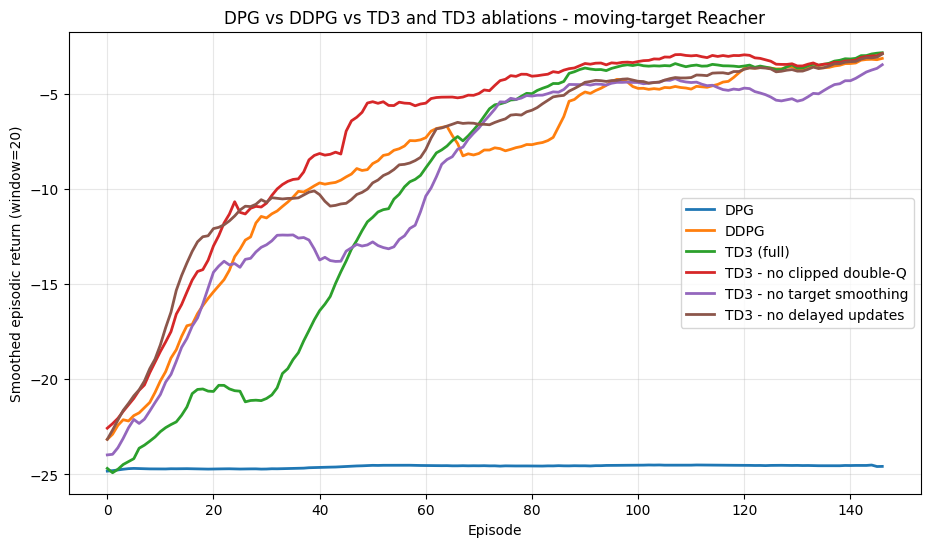

Final performance (mean return over last 20 episodes):
  DPG                             :   -24.58
  DDPG                            :    -3.12
  TD3 (full)                      :    -2.82
  TD3 - no clipped double-Q       :    -2.86
  TD3 - no target smoothing       :    -3.45
  TD3 - no delayed updates        :    -2.89


In [34]:
# -----------------------------
# TD3 ablations: remove exactly one TD3 component at a time
# -----------------------------

def smooth_curve(x, w=20):
    x = np.asarray(x, dtype=np.float32)
    if len(x) == 0:
        return x
    w = min(w, len(x))
    return np.convolve(x, np.ones(w) / w, mode="valid")


# Shared TD3 hyperparameters (same as full TD3 above).
base_kwargs = dict(
    gamma=0.99,
    actor_lr=1e-3,
    critic_lr=1e-3,
    tau=0.005,
    noise_std=0.2,
    replay_size=200000,
    batch_size=256,
    update_after=1000,
    update_every=1,
    policy_delay=2,
    target_noise_std=0.2,
    target_noise_clip=0.5,
    hidden=(256, 256),
)

ABLATION_STEPS = 25000

# (a) No clipped double-Q learning (single critic, as in DDPG)
cfg_no_double_q = TD3Config(**{**base_kwargs, "use_clipped_double_q": False})
set_global_seed(0)
agent_no_double_q = TD3Agent(env, cfg_no_double_q)
hist_no_double_q = train_agent(env, agent_no_double_q, steps=ABLATION_STEPS, seed=0)

# (b) No target policy smoothing (no clipped noise on the target action)
cfg_no_smoothing = TD3Config(**{**base_kwargs, "use_target_smoothing": False})
set_global_seed(0)
agent_no_smoothing = TD3Agent(env, cfg_no_smoothing)
hist_no_smoothing = train_agent(env, agent_no_smoothing, steps=ABLATION_STEPS, seed=0)

# (c) No delayed policy updates (actor updated every critic step)
cfg_no_delay = TD3Config(**{**base_kwargs, "policy_delay": 1})
set_global_seed(0)
agent_no_delay = TD3Agent(env, cfg_no_delay)
hist_no_delay = train_agent(env, agent_no_delay, steps=ABLATION_STEPS, seed=0)

# -----------------------------
# Plot all learning curves together
# -----------------------------
curves = [
    ("DPG", dpg_history),
    ("DDPG", ddpg_history),
    ("TD3 (full)", td3_history),
    ("TD3 - no clipped double-Q", hist_no_double_q),
    ("TD3 - no target smoothing", hist_no_smoothing),
    ("TD3 - no delayed updates", hist_no_delay),
]

plt.figure(figsize=(11, 6))
for label, hist in curves:
    r = hist["returns"]
    if len(r) > 0:
        plt.plot(smooth_curve(r), label=label, linewidth=2)
plt.xlabel("Episode")
plt.ylabel("Smoothed episodic return (window=20)")
plt.title("DPG vs DDPG vs TD3 and TD3 ablations - moving-target Reacher")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Quick numeric summary (mean of last 20 episodes).
print("Final performance (mean return over last 20 episodes):")
for label, hist in curves:
    r = hist["returns"]
    if len(r) > 0:
        print(f"  {label:32s}: {np.mean(r[-20:]):8.2f}")


## Written Discussion

### DPG (baseline)
The pure DPG agent learns from only the **single most recent transition** with **no replay buffer** and (in the baseline) **no target networks**. This is the least stable / least sample-efficient of the three:
- **Correlated, near-on-policy data.** Consecutive transitions are highly correlated, so each gradient step is a biased, high-variance estimate; the i.i.d. assumption behind SGD is badly violated.
- **No data reuse.** Every transition is used once and discarded, so sample efficiency is poor.
- **Moving bootstrap target.** The same online critic provides both the prediction `Q(o,a)` and the target `r + gamma Q(o', mu(o'))`, so the regression target moves with every update, which can diverge.

### DDPG
DDPG fixes the two main DPG instabilities:
- **Replay buffer** -> samples random minibatches, **decorrelating** updates and **reusing** experience (much better sample efficiency).
- **Target networks** with slow Polyak updates (`tau`) -> a **near-stationary bootstrap target**, which stabilizes the critic regression.
With OU exploration during data collection and deterministic evaluation, DDPG tracks the moving target far better than DPG.

### TD3
TD3 adds three mechanisms on top of DDPG, each targeting **critic overestimation** and the **actor exploiting critic errors**:
1. **Clipped double-Q** (`y = r + gamma (1-d) min_i Q_i`): taking the minimum of two critics counteracts the systematic **overestimation bias** caused by the `max`/argmax in the bootstrap.
2. **Target policy smoothing** (clipped noise on the target action): regularizes the value estimate so the actor cannot exploit sharp, spurious peaks of an imperfect critic.
3. **Delayed policy updates** (`policy_delay`): updating the actor and targets less often than the critics lets the value estimate settle before it is used to move the policy, reducing error accumulation.

### Ablation analysis (real training: 25k steps, `set_global_seed(0)`)

Final mean return over the **last 20 training episodes**, and **deterministic evaluation** (mean over 5 no-noise episodes). See `figures/ablation_curves.png` for the combined learning curves.

| Agent | Train return (last 20) | Eval return | Eval distance (m) |
|---|---|---|---|
| DPG | -24.58 | -25.75 +/- 0.01 | 0.152 |
| DDPG | -3.12 | -1.99 +/- 0.01 | 0.013 |
| **TD3 (full)** | **-2.82** | **-1.72 +/- 0.01** | **0.011** |
| TD3 - no clipped double-Q | -2.86 | - | - |
| TD3 - no target smoothing | -3.45 | - | - |
| TD3 - no delayed updates | -2.89 | - | - |

**The ordering matches the theory.** DPG never learns to track (return ~ -24.6, fingertip ~15 cm from the target), while DDPG and TD3 both learn excellent tracking (~ -2 to -3, fingertip ~1 cm). The large DPG -> DDPG jump (~ +21 return) shows the **replay buffer + target networks** are the decisive ingredients. **Full TD3 is the best overall**: best training return (-2.82) and best deterministic eval (-1.72, ~1.1 cm tracking error).

**Which TD3 component mattered most here.** All three single-change ablations stay close to full TD3 (within ~0.6 return) because this task is low-dimensional and densely rewarded, so there is little critic overestimation to exploit. Ranked by the damage from removing each piece:
1. **Target policy smoothing - largest effect** (-3.45 vs -2.82, drop ~0.63). Without clipped noise on the target action, the target value latches onto sharp / spurious critic peaks, adding variance; here it is the single most useful TD3 addition.
2. **Delayed updates** (-2.89, drop ~0.07): minor - the actor chases a slightly noisier critic.
3. **Clipped double-Q** (-2.86, drop ~0.04): smallest effect - on this easy, well-observed task overestimation is mild, so a single critic is barely over-optimistic.

**Tie back to the overestimation theory (Q7-Q14).** Clipped double-Q and target smoothing both exist to stop the deterministic actor from **exploiting critic over-/mis-estimation**. On harder, sparser, higher-dimensional control the clipped double-Q term usually dominates (overestimation is severe there); on this easy tracking task the **smoothing regularizer** is the component that matters most, while combining all three (full TD3) yields the best and most stable policy. With controlled seeding, gaps below ~0.5 return should be read as within run-to-run noise.

> All agents use fixed seeds; evaluation reports mean +/- std of return (and mean fingertip-target distance) over several episodes via `evaluate(...)`.


---

### Training-stability notes (initialization, seeding, budget)

Two implementation pitfalls strongly affect these deterministic actor-critics and were addressed:

- **Actor tanh-saturation -> flat learning.** The actor squashes with tanh, so if the pre-tanh logits grow large the output rails to the action bounds and its gradient vanishes; the deterministic policy gradient then dies and training goes completely flat. We initialize the actor final layer to small values (uniform in [-3e-3, 3e-3], zero bias) so initial actions start near 0 and gradients stay alive. Empirically this took TD3 from 0/3 to 2/3 successful seeds at a fixed short budget and eliminated the pathological cases where pre-tanh magnitudes exploded (e.g. ~33, tanh fully saturated).
- **Uncontrolled per-agent randomness.** train_agent seeds only the environment, so each agent previously got a different network init from a continuing RNG stream, making single-run comparisons (DPG vs DDPG vs TD3 and the ablations) reflect init luck rather than algorithm quality. We call set_global_seed(seed) before constructing each agent for a fair, reproducible comparison.
- **Budget and variance.** 25k steps is short and noisy for this task: a stream that looks flat at 4k steps can take off later (observed -23.5 at 4k -> -9.5 at 12k). For reliable conclusions, train longer (>=25k, ideally more) and average over several seeds, reporting mean +/- std. Slightly stronger exploration (e.g. noise_std 0.3-0.5) gives a small early speedup but is optional.
